In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ricardofernandes99/kkllk/Dataset-iGov.csv


# Importing the Data

In [2]:
df = pd.read_csv('/kaggle/input/datasets/ricardofernandes99/kkllk/Dataset-iGov.csv')
df.head()

,id_registo,data_registo,unidade_organizacional,tipo_servico,indicador_si,taxa_resolucao,tempo_resposta,satisfacao_cidadao,volume_interacoes,canal_utilizado,taxa_abandono,erros_tecnicos,transparencia,feedback_cidadao,segmentacao_utilizador,area_tematica,indicador_kpi
0,1,2024-04-12,Direcção De Serviços Financeiros,Telefone,83.02,87.37,36,3.8,368,Presencial,22.41,7,Sim,Processo Complicado,Empresa,Cultura,63.13
1,2,2024-12-14,Departamento De Inovação E Digitalização,Balcão Único,75.53,89.71,29,4.1,349,Email,14.87,1,Sim,Bom Serviço,Funcionário Público,Saúde,63.58
2,3,2024-09-27,Direcção De Recursos Humanos,Chatbot,85.73,75.96,38,3.3,398,Telefone,15.42,5,Não,Processo Complicado,Estudante,Inovação,73.64
3,4,2024-04-16,Departamento De Planeamento Estratégico,Email,78.33,73.82,57,3.4,74,Aplicacao_Movel,15.32,11,Sim,Processo Complicado,Funcionário Público,Digitalização,99.19
4,5,2024-03-12,Direcção De Recursos Humanos,Atendimento Presencial,81.82,70.41,97,4.7,487,Portal,7.47,4,Sim,Serviço Eficiente,Cidadão,Saúde,63.45


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_registo              200 non-null    int64  
 1   data_registo            200 non-null    object 
 2   unidade_organizacional  200 non-null    object 
 3   tipo_servico            200 non-null    object 
 4   indicador_si            200 non-null    float64
 5   taxa_resolucao          200 non-null    float64
 6   tempo_resposta          200 non-null    int64  
 7   satisfacao_cidadao      200 non-null    float64
 8   volume_interacoes       200 non-null    int64  
 9   canal_utilizado         200 non-null    object 
 10  taxa_abandono           200 non-null    float64
 11  erros_tecnicos          200 non-null    int64  
 12  transparencia           200 non-null    object 
 13  feedback_cidadao        200 non-null    object 
 14  segmentacao_utilizador  200 non-null    ob

# Checking for Missing Data

In [4]:
df.isnull().sum()

id_registo                0
data_registo              0
unidade_organizacional    0
tipo_servico              0
indicador_si              0
taxa_resolucao            0
tempo_resposta            0
satisfacao_cidadao        0
volume_interacoes         0
canal_utilizado           0
taxa_abandono             0
erros_tecnicos            0
transparencia             0
feedback_cidadao          0
segmentacao_utilizador    0
area_tematica             0
indicador_kpi             0
dtype: int64

We don't have any null values so that is good. We can proceed further to visualize the relations between the columns of the dataset.

# Visualizing the Data

# Multiple Linear Regression Model

In [33]:
#Independent Variables
X = df.drop(['indicador_kpi', 'data_registo'], axis=1)
y = df['indicador_kpi']


In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "unidade_organizacional",
    "tipo_servico",
    "canal_utilizado",
    "transparencia",
    "feedback_cidadao",
    "segmentacao_utilizador",
    "area_tematica"
]

ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

X = ct.fit_transform(X)

**Splitting the data into training and testing sets**

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/3, random_state = 0)

**Applying the Linear Regression model**

In [45]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

**The coefficients of the model**

In [57]:
regressor.coef_

array([-4.40684939,  3.52267136,  5.72564821, -3.89758291, -2.02003051,
        2.01245683, -3.78723614,  2.85092254,  3.11720128, -3.81468242,
       -2.71575927,  1.73670185,  1.27604338, -0.14075631,  0.54125149,
        1.37102555,  2.85781448, -0.45485406, -3.2467317 , -1.96977406,
        1.44251979, -0.47691758,  0.47691758, -2.72444542,  4.75782452,
        0.30146094, -0.95334008, -6.79463523, -0.65703514,  4.87725275,
       -0.53488531, -2.41390639,  4.14170934,  0.82254832,  1.18435424,
       -3.31603544,  0.65855293,  1.33154851, -0.68096856, -4.46283856,
        1.78354984,  0.74910574,  0.69330241,  4.87934535,  0.56853388,
        1.80207537, -8.10661375,  2.09353971, -0.01986785,  0.12491121,
        0.11990518,  0.02701008, -2.61555272, -0.01730539,  0.10100674,
        0.01753529])

**The intercept of the model**

In [47]:
regressor.intercept_

70.68530807907761

**Predicting the data using our model**

In [52]:
y_pred = regressor.predict(X_test)

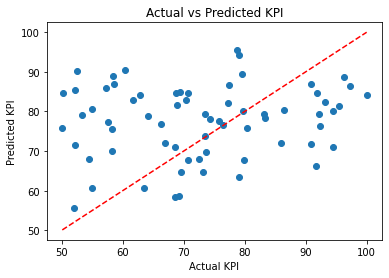

In [54]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual KPI")
plt.ylabel("Predicted KPI")
plt.title("Actual vs Predicted KPI")

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.show()

In [53]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
print('Mean Absolute Error = ',mean_absolute_error(y_test,y_pred))
print('R2 score = ',r2_score(y_test,y_pred))

Mean Absolute Error =  13.359278054746063
R2 score =  -0.36126561859963346


# **Polynomial Regression**

In [41]:
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree = 2)
X_poly = poly_reg.fit_transform(X_train)
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y_train)

LinearRegression()

In [42]:
y_pred1 = lin_reg.predict(poly_reg.transform(X_test))
print('Mean Absolute Error = ',mean_absolute_error(y_test,y_pred1))
print('R2 score = ',r2_score(y_test,y_pred1))

Mean Absolute Error =  24.05162928079282
R2 score =  -3.6947718416793673


# **Decision Tree Regressor**

In [43]:
from sklearn.tree import DecisionTreeRegressor
dec_reg = DecisionTreeRegressor(random_state = 0)
dec_reg.fit(X_train,y_train)

DecisionTreeRegressor(random_state=0)

In [44]:
y_pred2 = dec_reg.predict(X_test)
print('Mean Absolute Error = ',mean_absolute_error(y_test,y_pred2))
print('R2 score = ',r2_score(y_test,y_pred2))

Mean Absolute Error =  15.438358208955226
R2 score =  -1.0100398777116402


# **Random Forest Regression**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_reg = RandomForestRegressor(n_estimators = 10, random_state = 0)
rf_reg.fit(X_train,y_train)

In [ ]:
y_pred3 = dec_reg.predict(X_test)
print('Mean Absolute Error = ',mean_absolute_error(y_test,y_pred3))
print('R2 score = ',r2_score(y_test,y_pred3))

**It is seen that Polynomial Regression of degree 2 gives the most accurate result for the above dataset.**